**Sales & Margin Analytics System**

This project demonstrates the development of a comprehensive analytical system designed to manage sales performance, product profitability, customer behavior and employee effectiveness using real company data.

This notebook analyzes manager performance using real firm data.  
The data has been anonymized and partially synthesized to preserve confidentiality while maintaining the underlying structure and analytical value.

**The objective was not to build isolated reports, but to create a decision-support system combining:**

* Manager performance evaluation using econometric modeling
* Customer purchase probability prediction using Machine Learning
* Integration of model outputs into a BI dashboard for operational use

This work connects Econometrics, Machine Learning and Business Intelligence into a single analytical framework used for managerial decision-making.

The methods: Mixed Linear Model, XGBClassifier (Gradient Boosting)

<H1>Data and libraries loading</h1>

In [1370]:
!pip install shap

In [1371]:
!pip install linearmodels

In [1372]:
!pip install category-encoders

In [1373]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import r2_score, make_scorer, mean_squared_error, mean_absolute_error
import shap
import category_encoders as ce
from scipy import stats
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import het_breuschpagan
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
from statsmodels.stats.diagnostic import het_breuschpagan
import statsmodels.api as sm
from linearmodels.panel import PanelOLS, RandomEffects

In [1416]:
df=pd.read_excel('/content/source.xlsx')
product=pd.read_excel('/content/Produkt.xlsx')

In [1417]:
pd.options.display.float_format = '{:.2f}'.format

In [1418]:
df.head()

,Bestellung,Produkt,Kunde,Auftragsbetreuer,Menge,Ausgabedatum,Variable Kosten,Verkaufspreis,Listenpreis,AuftragsbetreuerID,KundenID,ProduktID
0,99739,M6X25 VERSCHLUSS,ALAMAK,Bondarenko,401,2024-03-06 12:41:37,82.11,87.00,0.00,1,10001,1021
1,99740,M10X25 BOLZEN,ALAMAK,Bondarenko,28,2024-04-16 16:24:26,110.49,0.13,0.00,1,10001,1007
2,99741,M12X40 BOLZEN,ALAMAK,Bogun,8,2023-12-26 16:00:02,22.45,24.02,0.00,2,10001,1012
3,99742,M20X40 BLACK BOLT,ALAMAK,Bogun,17,2023-12-26 16:00:59,110.93,118.70,0.00,2,10001,1017
4,99743,M6X40 VERSCHLUSS,ALAMAK,Bondarenko,1697,2024-03-06 12:39:11,133.74,144.00,0.00,1,10001,1022


In [1419]:
product.head()

,ProduktID,Artikel,Warengruppe,Untergruppe
0,1,"0,4 KVA-VERMITTLUNGSZENTRALE",Transformatorstation,KVA
1,2,1 TR-RA-WICKLUNG 10 KV,Elektrotechnische Erzeugnisse,Wicklung
2,3,10 KV STROMWICKLUNG 2 TR-RA,Elektrotechnische Erzeugnisse,Wicklung
3,4,10 KV STROMWICKLUNG 3 TR-RA,Elektrotechnische Erzeugnisse,Wicklung
4,5,100X112X25,Metallprodukte und Halbzeuge,Metallschrank


In [1420]:
df=pd.merge(df, product, how="left", left_on="ProduktID", right_on="ProduktID")

<h1>2. Data Understanding and data preprocessing </h1>

<h2>2.1 Data understanding</h2>

In [1421]:
df.isnull().sum()

,0
Bestellung,0
Produkt,0
Kunde,58
Auftragsbetreuer,0
Menge,0
Ausgabedatum,0
Variable Kosten,0
Verkaufspreis,0
Listenpreis,0
AuftragsbetreuerID,0


In [1422]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12524 entries, 0 to 12523
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Bestellung          12524 non-null  int64         
 1   Produkt             12524 non-null  object        
 2   Kunde               12466 non-null  object        
 3   Auftragsbetreuer    12524 non-null  object        
 4   Menge               12524 non-null  int64         
 5   Ausgabedatum        12524 non-null  datetime64[ns]
 6   Variable Kosten     12524 non-null  float64       
 7   Verkaufspreis       12524 non-null  float64       
 8   Listenpreis         12524 non-null  float64       
 9   AuftragsbetreuerID  12524 non-null  int64         
 10  KundenID            12524 non-null  int64         
 11  ProduktID           12524 non-null  int64         
 12  Artikel             12524 non-null  object        
 13  Warengruppe         12524 non-null  object    

<h2>2.2 Data preprocessing</h2>

Remove unnecessary columns

In [1423]:
df = df.drop(columns=[ "Produkt", "Artikel", "Kunde"])

Creating additional columns

In [1424]:
df['date'] = pd.to_datetime(df['Ausgabedatum'])
df = df.drop(columns=["Ausgabedatum"])
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

In [1425]:
df['Deckungsbeitrag'] = df['Verkaufspreis']-df['Variable Kosten']

In [1426]:
# Listenpreis under 65 it`s noice and mistakes
diff = df["Verkaufspreis"] - df["Listenpreis"]

df["Rabatt"] = -diff.where(
    (df["Listenpreis"] >= 65) & (diff <= 0),
    0
)

In [1427]:
diff = df["Verkaufspreis"] - df["Listenpreis"]

df["Aufschlag"] = np.where(
    (df["Listenpreis"] < 65) | (diff < 0),
    0,
    diff
)

In [1428]:
df.head()

,Bestellung,Auftragsbetreuer,Menge,Variable Kosten,Verkaufspreis,Listenpreis,AuftragsbetreuerID,KundenID,ProduktID,Warengruppe,Untergruppe,date,month,year,Deckungsbeitrag,Rabatt,Aufschlag
0,99739,Bondarenko,401,82.11,87.00,0.00,1,10001,1021,Metallprodukte und Halbzeuge,Befestigungselemente,2024-03-06 12:41:37,3,2024,4.89,-0.00,0.00
1,99740,Bondarenko,28,110.49,0.13,0.00,1,10001,1007,Metallprodukte und Halbzeuge,Befestigungselemente,2024-04-16 16:24:26,4,2024,-110.36,-0.00,0.00
2,99741,Bogun,8,22.45,24.02,0.00,2,10001,1012,Metallprodukte und Halbzeuge,Befestigungselemente,2023-12-26 16:00:02,12,2023,1.57,-0.00,0.00
3,99742,Bogun,17,110.93,118.70,0.00,2,10001,1017,Metallprodukte und Halbzeuge,Befestigungselemente,2023-12-26 16:00:59,12,2023,7.77,-0.00,0.00
4,99743,Bondarenko,1697,133.74,144.00,0.00,1,10001,1022,Metallprodukte und Halbzeuge,Befestigungselemente,2024-03-06 12:39:11,3,2024,10.26,-0.00,0.00


In [1429]:
df.describe()

,Bestellung,Menge,Variable Kosten,Verkaufspreis,Listenpreis,AuftragsbetreuerID,KundenID,ProduktID,date,month,year,Deckungsbeitrag,Rabatt,Aufschlag
count,12524.00,12524.00,12524.00,12524.00,12524.00,12524.00,12524.00,12524.00,12524,12524.00,12524.00,12524.00,12524.00,12524.00
mean,127892.46,63.84,20170.09,44492.69,40498.38,6.58,10199.66,1931.01,2021-11-01 21:38:26.653864704,6.25,2021.36,24322.60,6541.65,2103.65
min,99739.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,2018-06-26 00:00:00,1.00,2018.00,-1244629.71,-0.00,0.00
25%,110818.00,2.00,236.45,151.80,0.04,0.00,10031.00,1109.00,2020-04-30 10:27:54.750000128,4.00,2020.00,0.00,-0.00,0.00
50%,130296.00,4.00,1996.80,2810.54,2520.00,6.00,10079.00,1773.00,2022-01-25 09:00:14.500000,6.00,2022.00,880.37,-0.00,0.00
75%,140724.00,10.00,14014.31,24916.63,23949.60,10.00,10360.00,2871.00,2023-05-19 08:20:39.249999872,9.00,2023.00,13272.76,0.00,0.00
max,281020.00,42321.00,2535024.00,8334900.00,7225920.00,26.00,10877.00,3990.00,2024-05-31 15:12:08,12.00,2024.00,6847026.97,6153536.81,1470203.47
std,16782.89,649.04,72917.91,176690.38,166865.66,5.52,373.94,1084.59,NaN,3.39,1.83,124448.04,100882.99,23823.66


In [1430]:
df.columns = df.columns.str.replace(" ", "_")

Removal of anomalies. Z-score is 3

In [1431]:
df_clean = df[(np.abs(stats.zscore(df['Verkaufspreis'])) < 3)]

In [1432]:
df_clean.describe()

,Bestellung,Menge,Variable_Kosten,Verkaufspreis,Listenpreis,AuftragsbetreuerID,KundenID,ProduktID,date,month,year,Deckungsbeitrag,Rabatt,Aufschlag
count,12379.00,12379.00,12379.00,12379.00,12379.00,12379.00,12379.00,12379.00,12379,12379.00,12379.00,12379.00,12379.00,12379.00
mean,127853.58,62.41,15523.15,30601.37,30970.93,6.55,10197.99,1928.48,2021-10-30 07:03:58.257128960,6.25,2021.35,15078.22,5529.21,1385.51
min,99739.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,2018-06-26 00:00:00,1.00,2018.00,-1244629.71,-0.00,0.00
25%,110814.50,2.00,228.08,138.00,0.04,0.00,10031.00,1109.00,2020-04-27 12:03:27.500000,4.00,2020.00,0.00,-0.00,0.00
50%,130296.00,4.00,1949.57,2646.00,2500.00,6.00,10079.00,1765.00,2022-01-24 12:47:30,6.00,2022.00,811.16,0.00,0.00
75%,140722.50,10.00,13085.96,23080.56,22650.00,10.00,10358.00,2870.00,2023-05-17 16:13:36,9.00,2023.00,12173.48,0.00,0.00
max,281020.00,42321.00,1351135.71,573750.00,3845632.00,26.00,10877.00,3990.00,2024-05-31 15:12:08,12.00,2024.00,524831.13,3834095.10,357500.00
std,16795.93,635.93,37823.56,69785.02,92482.81,5.52,374.49,1083.13,NaN,3.38,1.83,49973.47,65707.85,8928.85


<H2>2.3 X,y-values and test, train data </h2>

In [1433]:
df=df_clean
df[['Menge','Variable_Kosten','Verkaufspreis','Rabatt','Aufschlag']] = np.log1p(df[['Menge','Variable_Kosten','Verkaufspreis','Rabatt','Aufschlag']])

In [1434]:
features = ['Menge','Variable_Kosten','Verkaufspreis','Rabatt','Aufschlag','Auftragsbetreuer',
    'KundenID',
    'ProduktID',
    'month',
    'year']

Category data preprocessing

In [1435]:
cat_cols = [
    'Auftragsbetreuer',
    'KundenID',
    'ProduktID',
    'month',
    'year',
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [1436]:
X = df[features]
y = df['Deckungsbeitrag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h1>3. Manager Performance Evaluation (Econometric Approach)</h1>

A common mistake in sales analytics is evaluating managers by revenue or margin alone.
Such metrics are heavily biased by:

* product mix
* customer portfolio
* customer portfolio
* pricing policy
* seasonality
* year-specific effects

To isolate the true individual contribution of each manager, a Mixed Linear Model (MixedLM) with random intercepts per manager was implemented.

This approach allows us to separate:
observable business factors from the unobservable manager effect.

The random effect obtained from the model represents the cleaned managerial contribution after controlling for all measurable influences.

In [1437]:
df_model = df.copy()
df_model["AuftragsbetreuerID"] = df_model["AuftragsbetreuerID"].astype("category")

In [1438]:
formula = """
Deckungsbeitrag ~ Menge + Variable_Kosten + Verkaufspreis + Rabatt + Aufschlag + month + year
"""

In [1439]:
model = smf.mixedlm(
    formula,
    df_model,
    groups=df_model["AuftragsbetreuerID"]
)
result = model.fit()

In [1440]:
print(result.summary())

                  Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     Deckungsbeitrag
No. Observations:     12379       Method:                 REML           
No. Groups:           27          Scale:                  1827712916.0049
Min. group size:      6           Log-Likelihood:         -149399.6108   
Max. group size:      3178        Converged:              Yes            
Mean group size:      458.5                                              
-------------------------------------------------------------------------
                   Coef.     Std.Err.    z    P>|z|   [0.025     0.975]  
-------------------------------------------------------------------------
Intercept            477.024 2952.939   0.162 0.872  -5310.631   6264.678
month[T.2]          -284.687 1975.597  -0.144 0.885  -4156.786   3587.412
month[T.3]         -1407.103 1841.574  -0.764 0.445  -5016.523   2202.316
month[T.4]          -500.272 1770.575  -0.283 0.778  -39

In [1441]:
manager_effects = result.random_effects

In [1442]:
manager_df = pd.DataFrame.from_dict(manager_effects, orient="index")
manager_df = manager_df.reset_index()
manager_df.columns = ["Auftragsbetreuer", "effect"]

In [1443]:
y_pred = result.fittedvalues

rmse = mean_squared_error(df_model["Deckungsbeitrag"], y_pred)
mae = mean_absolute_error(df_model["Deckungsbeitrag"], y_pred)
r2 = r2_score(df_model["Deckungsbeitrag"], y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

RMSE: 1821559030.0048
MAE: 22410.7994
R²: 0.2705


In the context of econometric analysis, an R² of 0.2705 can be considered acceptable, as a substantial part of the variability is typically driven by unobserved factors.

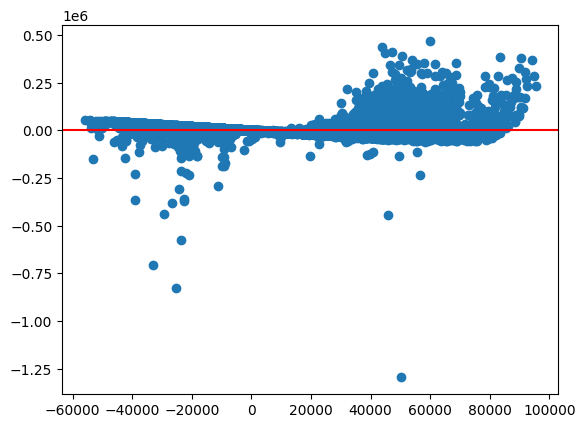

In [1444]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red")

In [1445]:
print(result.cov_re)

            Group
Group 52007710.83


cov_re represents the estimated variance of the random intercepts across managers, indicating how strongly profitability differs systematically between AuftragsbetreuerID groups.

In [1446]:
residuals = result.resid
exog = result.model.exog
bp_test = het_breuschpagan(residuals, exog)
print("Breusch-Pagan p-value:", bp_test[1])

Breusch-Pagan p-value: 2.173117150346089e-34


The Breusch–Pagan test indicates significant heteroskedasticity (p < 0.001). Therefore, robust standard errors are used to ensure reliable statistical inference.

In [1447]:
# Hausman test
df_panel = df.copy()
df_panel["year"] = df_panel["year"].astype(int)
df_panel = df_panel.set_index(["AuftragsbetreuerID", "year"])

y = df_panel["Deckungsbeitrag"]

X = df_panel[[
    "Menge",
    "Variable_Kosten",
    "Verkaufspreis",
    "Rabatt",
    "Aufschlag"
]]

X = sm.add_constant(X)

fe_model = PanelOLS(y, X, entity_effects=True)
fe_res = fe_model.fit()
re_model = RandomEffects(y, X)
re_res = re_model.fit()

b_FE = fe_res.params
b_RE = re_res.params

common_coef = b_FE.index.intersection(b_RE.index)

b_FE = b_FE[common_coef]
b_RE = b_RE[common_coef]


diff = b_FE - b_RE

cov_FE = fe_res.cov.loc[common_coef, common_coef]
cov_RE = re_res.cov.loc[common_coef, common_coef]

stat = np.dot(np.dot(diff.T, np.linalg.inv(cov_FE - cov_RE)), diff)

df = len(diff)

p_value = 1 - stats.chi2.cdf(stat, df)

print(f"Hausman test statistic: {stat:.4f}")
print(f"p-value: {p_value:.6f}")

Hausman test statistic: 110.1319
p-value: 0.000000


Although the Hausman test rejects the Random Effects specification for causal inference, the mixed-effects model remains useful for decomposing outcome variability at the manager level, enabling the construction of performance-based KPIs.

Mixedlm represents the manager's contribution after controlling for all observable business factors.

The random intercept extracted for each manager represents:

the expected contribution to margin after removing the influence of product, price, customer, seasonality and year effects.

This value is later standardized (Z-score) and integrated into the BI dashboard as Bereinigter Mitarbeiterbeitrag (Cleaned Manager Contribution).

In [1448]:
residuals = df_model["Deckungsbeitrag"] - y_pred

In [1449]:
manager_df["effect_z"] = (
    manager_df["effect"] - manager_df["effect"].mean()
) / manager_df["effect"].std()


In [1450]:
manager_df ["year"] = "all"

In [1451]:
manager_df.head(100)

,Auftragsbetreuer,effect,effect_z,year
0,0,-1491.81,-0.24,all
1,1,-4367.32,-0.71,all
2,2,-3240.96,-0.53,all
3,3,-98.60,-0.02,all
4,4,-2110.85,-0.35,all
5,5,1305.78,0.21,all
6,6,-6943.78,-1.14,all
7,7,-1816.62,-0.30,all
8,8,-3043.68,-0.50,all
9,9,-3373.66,-0.55,all


In [1452]:
results_all = []

for i in range(2018, 2025):
    year_df = df_model[df_model["year"] == i]

    if year_df.shape[0] < 10 or year_df["AuftragsbetreuerID"].nunique() < 3:
        print(f"Skip year {i} (not enough data)")
        continue

    formula = """
    Deckungsbeitrag ~ Menge + Variable_Kosten + Verkaufspreis + Listenpreis + Rabatt + Aufschlag
    """

    model_t = smf.mixedlm(
        formula,
        year_df,
        groups=year_df["AuftragsbetreuerID"]
    )

    try:
        result_t = model_t.fit(reml=False)

    except Exception as e:
        print(f"Year {i} failed: {e}")
        continue

    manager_effects_t = result_t.random_effects

    manager_df_t = pd.DataFrame.from_dict(manager_effects_t, orient="index")
    manager_df_t = manager_df_t.reset_index()
    manager_df_t.columns = ["AuftragsbetreuerID", "effect"]

    manager_df_t["effect_z"] = (
        (manager_df_t["effect"] - manager_df_t["effect"].mean())
        / manager_df_t["effect"].std()
    )

    manager_df_t["year"] = i

    results_all.append(manager_df_t)

manager_df_t = pd.concat(results_all, ignore_index=True)


Skip year 2019 (not enough data)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [1453]:
manager_df_t.head(100)

,AuftragsbetreuerID,effect,effect_z,year
0,0,-22359.43,-3.32,2018
1,2,40.29,0.01,2018
2,3,6209.49,0.92,2018
3,4,1400.01,0.21,2018
4,5,342.53,0.05,2018
...,...,...,...,...
95,3,0.41,0.12,2024
96,5,0.64,0.18,2024
97,6,0.31,0.09,2024
98,7,-0.50,-0.14,2024


In [1454]:
dim_mageffect = pd.concat(
    [manager_df, manager_df_t],
    axis=0,
    ignore_index=True
)

<h1>4. Customer Purchase Probability (60-day Horizon) — Machine Learning Model </h1>

**To support proactive sales actions, a Machine Learning model was developed to predict the probability of a customer placing an order within the next 60 days.**

The dataset is split using a time-based cutoff to prevent data leakage:

Training data: historical orders before cutoff date
Target: whether the customer purchases in the following 60 days

This transforms the problem into a realistic forward-looking prediction task.

In [1459]:
df=pd.read_excel('/content/source.xlsx')

In [1464]:
df_clean.dtypes

,0
Bestellung,int64
Auftragsbetreuer,category
Menge,float64
Variable_Kosten,float64
Verkaufspreis,float64
Listenpreis,float64
AuftragsbetreuerID,int64
KundenID,category
ProduktID,category
Warengruppe,object


In [1466]:
df = df_clean.sort_values("date")

In [1467]:
df.head()

,Bestellung,Auftragsbetreuer,Menge,Variable_Kosten,Verkaufspreis,Listenpreis,AuftragsbetreuerID,KundenID,ProduktID,Warengruppe,Untergruppe,date,month,year,Deckungsbeitrag,Rabatt,Aufschlag
5621,130073,Semerak,1.61,8.04,0.00,5346.00,6,10198,1164,Messtransformator,OMP,2018-06-26,6,2018,-3115.64,8.58,0.00
8590,140432,Ryabchenko,1.10,7.21,0.00,6400.00,9,10031,3068,Messtransformator,TOL,2018-06-26,6,2018,-1352.82,8.76,0.00
10742,150176,Ryabchenko,3.43,6.74,0.00,3360.00,9,10031,2037,Elektrotechnische Erzeugnisse,Elektrotechnische Bauteile,2018-06-26,6,2018,-845.10,8.12,0.00
9989,140952,Piven,1.95,7.64,0.00,2547.60,8,10512,1745,Messtransformator,OSM,2018-06-26,6,2018,-2071.71,7.84,0.00
8481,140381,Ryabchenko,0.69,6.23,0.00,3200.00,9,10031,3061,Messtransformator,TOL,2018-06-26,6,2018,-505.22,8.07,0.00


**Feature Engineering**

Instead of relying on raw transactional data, meaningful behavioral features were engineered:


* Repeat rate
* Log-scaled recency of buying
* Log-scaled order activity

These features capture purchasing behavior patterns and significantly improve model quality.

In [1468]:
cuttoff = df['date'].max() - pd.Timedelta(days=60)

In [1469]:
train = df[df["date"] <= cuttoff]
test_period = df[df["date"] > cuttoff]

In [1470]:
reference_date = train["date"].max()
recency = train.groupby("KundenID")["date"].max().reset_index()
recency["recency_days"] = (reference_date - recency["date"]).dt.days
lifetime = train.groupby("KundenID")["date"].agg(["min", "max"]).reset_index()
lifetime["lifetime_days"] = (lifetime["max"] - lifetime["min"]).dt.days

/tmp/ipykernel_9709/2782357285.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency = train.groupby("KundenID")["date"].max().reset_index()
/tmp/ipykernel_9709/2782357285.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lifetime = train.groupby("KundenID")["date"].agg(["min", "max"]).reset_index()


In [1471]:
train = train.sort_values(["KundenID", "date"])
train["date"] = pd.to_datetime(train["date"])

In [1472]:
X = train.groupby("KundenID").agg(
    num_orders=("Bestellung", "nunique"),
    num_products=("ProduktID", "nunique"),
    total_revenue=("Verkaufspreis", "sum"),
    num_items=("ProduktID", "count"),
    num_orders_2023 = ("year", lambda x: ((x == 2023) | (x == 2024)).sum())
).reset_index()

/tmp/ipykernel_9709/1090234647.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  X = train.groupby("KundenID").agg(


Selecting X-features

In [1473]:
X = X.merge(recency[["KundenID", "recency_days"]], on="KundenID")
X = X.merge(lifetime[["KundenID", "lifetime_days"]], on="KundenID")

# X-values
X["recency_ratio"] = X["recency_days"] / (X["lifetime_days"] + 1)
X["repeat_rate"] = X["num_orders"] / (X["num_products"] + 1)
X["recency_log"] = np.log1p(X["recency_days"])
X["revenue_log"] = np.log1p(X["total_revenue"])
# --- TARGET ---
future_buyers = test_period["KundenID"].unique()
y = X["KundenID"].isin(future_buyers).astype(int)
X["num_orders_log"] = np.log1p(X["num_orders"])
X["num_orders_2023_log"] = np.log1p(X["num_orders_2023"])
# --- FINAL DATA ---
X_final = X.drop(columns=["KundenID","num_products", "lifetime_days", "recency_days","total_revenue", "num_products", "num_items", "num_orders", "num_orders_2023","num_orders_log", "revenue_log", "recency_ratio"])

In [1515]:
X_final.head()

,repeat_rate,recency_log,num_orders_2023_log
0,0.71,4.79,1.39
1,0.47,2.08,4.62
2,1.03,3.40,3.33
3,0.43,0.69,4.44
4,0.50,4.80,1.39


In [1475]:
XGB_model = XGBClassifier(
    n_estimators=200,
    max_depth=32,
    learning_rate=0.1,
    subsample=0.8,
    monotone_constraints=(1,-1,1)
)

model = CalibratedClassifierCV(
    XGB_model,
    method= "sigmoid",
    cv=2
)

model.fit(X_final, y)

CalibratedClassifierCV(cv=2,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric=None,
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.1, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=32, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=(1, -1, 1),
                                               multi_strategy=None,
                                               n_estimators=200, n_jobs=None,
                                               num_parallel_tree=None, ...))

In [1476]:
X["probability_60d"] = model.predict_proba(X_final)[:, 1]

In [1477]:
from sklearn.metrics import precision_recall_curve

In [1478]:
precision, recall, thresholds = precision_recall_curve(y, y_proba)
fscore = 2 * precision * recall / (precision + recall)
ix = np.argmax(fscore)
best_threshold = thresholds[ix]

In [1488]:
y_proba = model.predict_proba(X_final)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

In [1489]:
xgb_model = model.calibrated_classifiers_[0].estimator

explainer = shap.Explainer(xgb_model, X_final)

shap_values = explainer(X_final)

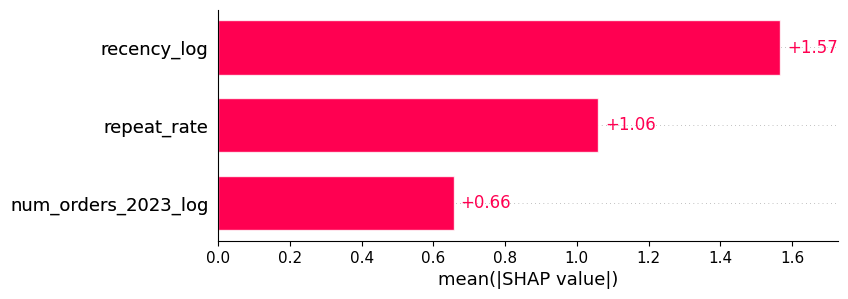

In [1490]:
shap.plots.bar(shap_values)

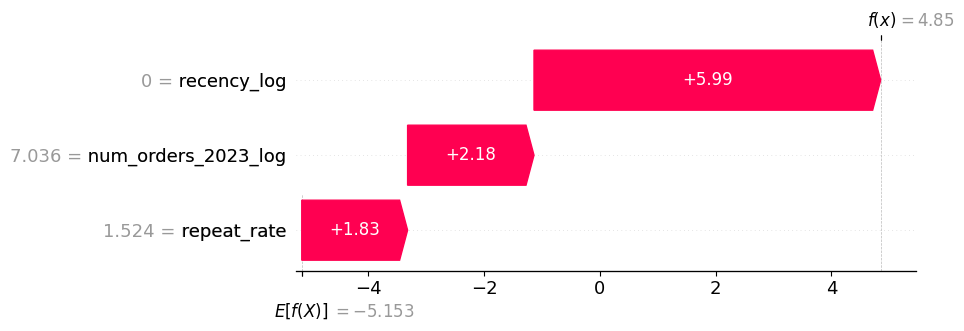

In [1504]:
shap.plots.waterfall(shap_values[31])

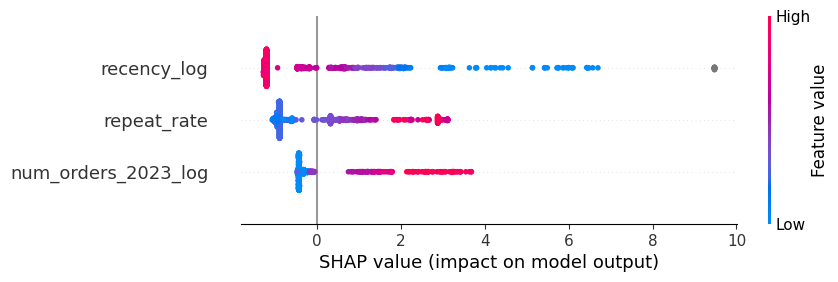

In [1509]:
shap.plots.beeswarm(shap_values)

In [1510]:
print("roc_auc_score:", roc_auc_score(y, y_proba))
print("Precision:", precision_score(y, y_pred))
print("Recall:", recall_score(y, y_pred))
print("F1-score:", f1_score(y, y_pred))

print(classification_report(y, y_pred))

roc_auc_score: 0.9536747994194803
Precision: 0.6814159292035398
Recall: 0.8191489361702128
F1-score: 0.7439613526570048
              precision    recall  f1-score   support

           0       0.98      0.95      0.97       777
           1       0.68      0.82      0.74        94

    accuracy                           0.94       871
   macro avg       0.83      0.89      0.85       871
weighted avg       0.95      0.94      0.94       871



In [1511]:
# Function for confusion matrix
def plot_confusion_matrix(y,y_predict):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True,fmt="d", ax = ax);
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['0', '1']); ax.yaxis.set_ticklabels(['0', '1'])

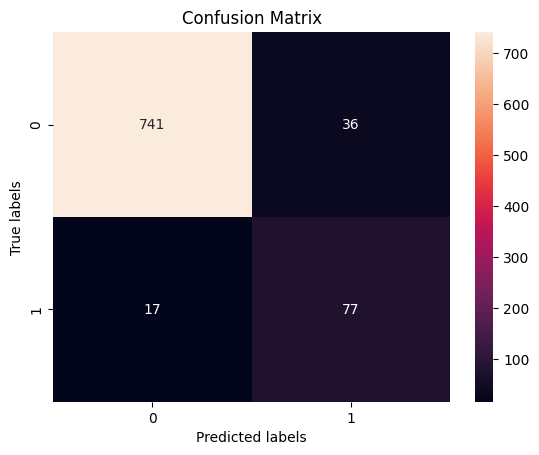

In [1513]:
plot_confusion_matrix (y, y_pred)

Model Performance and Calibration

The model achieves high ROC-AUC and recall, which is critical for identifying customers likely to purchase soon.

In the model, **recall (82%)** is much higher than **precision (68%)**. In the sales department, a "false positive" is relatively cheap — it results in only one additional call from a salesperson. However, a "false negative" is much more expensive, as it represents lost potential profit. Therefore **the model is configured to minimize the risk of missed sales opportunities**.

Probability calibration is applied to ensure that predicted probabilities can be interpreted as real purchase likelihoods, making the output suitable for operational sales prioritization.

SHAP analysis is used to provide explainability of the model decisions.

In [1514]:
result = X[["KundenID", "probability_60d", "num_orders"]].sort_values(
    "probability_60d", ascending=False
)

print(result.head(50))

    KundenID  probability_60d  num_orders
31     10031             0.87         823
137    10137             0.87         240
60     10060             0.87         108
359    10360             0.87          53
33     10033             0.87          52
30     10030             0.86          68
3      10003             0.86          62
29     10029             0.85          58
1      10001             0.85          65
258    10258             0.85          18
13     10013             0.85          66
770    10775             0.84           4
2      10002             0.84          36
372    10373             0.83          21
78     10078             0.83          69
19     10019             0.83           5
141    10141             0.82          58
23     10023             0.82          12
810    10817             0.81           6
640    10644             0.81          13
834    10841             0.81           4
595    10599             0.81          36
15     10015             0.80     

In [1496]:
model.predict_proba(X_final)[:, 1].std()

np.float64(0.18570271608339847)

**Integration with Business Intelligence**

The outputs of both models are exported and integrated into the Power BI dashboard:

* Cleaned manager contribution for performance evaluation
* Customer purchase probability for sales prioritization

This ensures that advanced analytics directly supports daily managerial decisions.

In [1495]:
result.to_excel("dim_segmentirung.xlsx", index=False)

In [1455]:
dim_mageffect.to_excel("dim_mageffect.xlsx", index=False)